## Data Probe
Explores the ground water well log dataset for the boardman area
15 townships are included: 
T5N R25E, T5N R26E, T5N R27E, 
T4N R24E, T4N R25E, T4N R26E, T4N R27E, 
T3N R24E, T3N R25E, T3N R26E, T3N R27E,
T2N R24E, T2N R25E, T2N R26E, T2N R27E.

These townships covers the surrounding area (magenta) for the boardman site (red).


<img src="figures/township_boardman.png" width="50%">

In [9]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt

In [10]:
files = sorted(Path("../01_raw/wells").rglob("lithology.csv"))
counts = []
for path in files:
    with path.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)  # skip header
        count = sum(any(cell.strip() for cell in row) for row in rows)
    if count:
        counts.append(count)

if not counts:
    raise SystemExit("No lithology data found.")

print(f"Wells with non-empty lithology: {len(counts)}")
print(f"Total lithology files checked: {len(files)}")

Wells with non-empty lithology: 3063
Total lithology files checked: 7398


Histogram saved to: ../05_notebooks/figures/lithology_row_counts.png


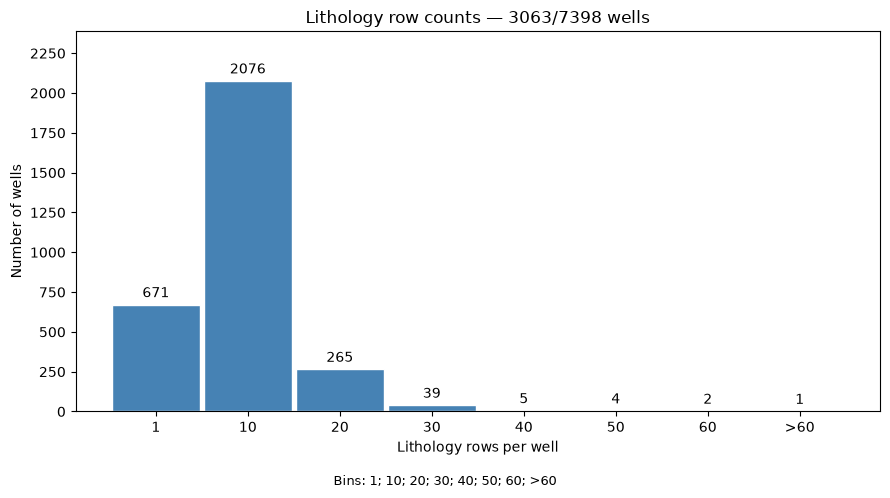

In [11]:
ranges = [(1, 1), (2, 10), (11, 20), (21, 30), (31, 40),
          (41, 50), (51, 60)]
labels = ["1", "10", "20", "30", "40", "50", "60"]
frequencies = [
    sum(low <= count <= high for count in counts)
    for low, high in ranges
]

if max(counts) > 60:
    labels.append(">60")
    frequencies.append(sum(count > 60 for count in counts))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, frequencies, width=0.95,
              color="steelblue", edgecolor="white")

ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Lithology rows per well")
ax.set_ylabel("Number of wells")
ax.set_title(f"Lithology row counts — {len(counts)}/{len(files)} wells")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.margins(y=0.15)
fig.text(0.5, 0.02,
         "Bins: 1; 10; 20; 30; 40; 50; 60; >60",
         ha="center", fontsize=9)
fig.tight_layout(rect=[0, 0.05, 1, 1])

output = Path("../05_notebooks/figures/lithology_row_counts.png")
output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output, dpi=200)
print(f"Histogram saved to: {output}")
plt.show()

### Extract Lat Lon for wells with lithology info (including wells with only one row of lithology)

In [12]:
import json
import csv
from pathlib import Path
wells_dir = Path("../01_raw/wells")
output = Path("../03_processed/wells/well_with_lithology.csv")
records = []

for lithology in sorted(wells_dir.rglob("lithology.csv")):
    with lithology.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)
        if not any(any(cell.strip() for cell in row) for row in rows):
            continue

    metadata_path = lithology.parent / "metadata.json"
    if not metadata_path.exists():
        print(f"Skipped {lithology.parent.name}: missing metadata.json")
        continue

    with metadata_path.open(encoding="utf-8") as f:
        metadata = json.load(f)

    records.append({
        "well_number": lithology.parent.name,
        "wl_id": metadata.get("wl_id"),
        "latitude": metadata.get("latitude_dec"),
        "longitude": metadata.get("longitude_dec"),
    })

output.parent.mkdir(parents=True, exist_ok=True)
with output.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=["well_number", "wl_id", "latitude", "longitude"]
    )
    writer.writeheader()
    writer.writerows(records)

print(f"Saved {len(records)} wells to {output}")

Saved 3063 wells to ../03_processed/wells/well_with_lithology.csv


### Extract Lat Lon for wells with lithology info (excluding wells with only one row of lithology)

In [13]:
import json
import csv
from pathlib import Path
wells_dir = Path("../01_raw/wells")
output = Path("../03_processed/wells/well_with_lithology_greater_than_one_row.csv")
records = []
for lithology in sorted(wells_dir.rglob("lithology.csv")):
    with lithology.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)
        count = sum(any(cell.strip() for cell in row) for row in rows)

    if count <= 1:
        continue

    metadata_path = lithology.parent / "metadata.json"
    if not metadata_path.exists():
        print(f"Skipped {lithology.parent.name}: missing metadata.json")
        continue

    with metadata_path.open(encoding="utf-8") as f:
        metadata = json.load(f)

    records.append({
        "well_number": lithology.parent.name,
        "wl_id": metadata.get("wl_id"),
        "latitude": metadata.get("latitude_dec"),
        "longitude": metadata.get("longitude_dec"),
    })

output.parent.mkdir(parents=True, exist_ok=True)
with output.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=["well_number", "wl_id", "latitude", "longitude"]
    )
    writer.writeheader()
    writer.writerows(records)

print(f"Saved {len(records)} wells to {output}")

Saved 2392 wells to ../03_processed/wells/well_with_lithology_greater_than_one_row.csv


### Extract Lat Lon for wells with lithology info (excluding wells with less than 10 row of lithology)

In [14]:
import json
import csv
from pathlib import Path
wells_dir = Path("../01_raw/wells")
output = Path("../03_processed/wells/well_with_lithology_greater_than_ten_row.csv")
records = []
for lithology in sorted(wells_dir.rglob("lithology.csv")):
    with lithology.open(encoding="utf-8-sig", newline="") as f:
        rows = csv.reader(f)
        next(rows, None)
        count = sum(any(cell.strip() for cell in row) for row in rows)

    if count < 10:
        continue

    metadata_path = lithology.parent / "metadata.json"
    if not metadata_path.exists():
        print(f"Skipped {lithology.parent.name}: missing metadata.json")
        continue

    with metadata_path.open(encoding="utf-8") as f:
        metadata = json.load(f)

    records.append({
        "well_number": lithology.parent.name,
        "wl_id": metadata.get("wl_id"),
        "latitude": metadata.get("latitude_dec"),
        "longitude": metadata.get("longitude_dec"),
    })

output.parent.mkdir(parents=True, exist_ok=True)
with output.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=["well_number", "wl_id", "latitude", "longitude"]
    )
    writer.writeheader()
    writer.writerows(records)

print(f"Saved {len(records)} wells to {output}")

Saved 417 wells to ../03_processed/wells/well_with_lithology_greater_than_ten_row.csv


## Processed figure showing water wells with lithology data
<img src="figures/water_wells_with_lithology_intervals.png" width="80%">

Explore the relationship between the depth of the well and the number of intervals

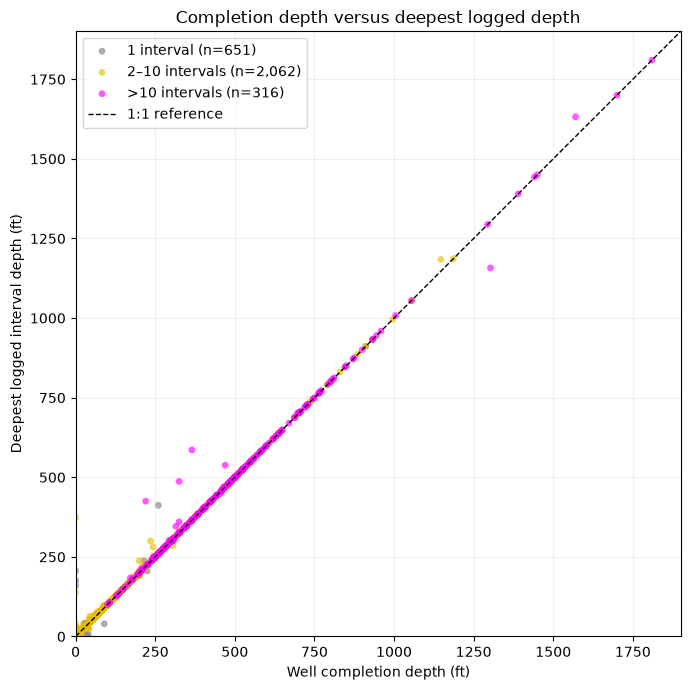

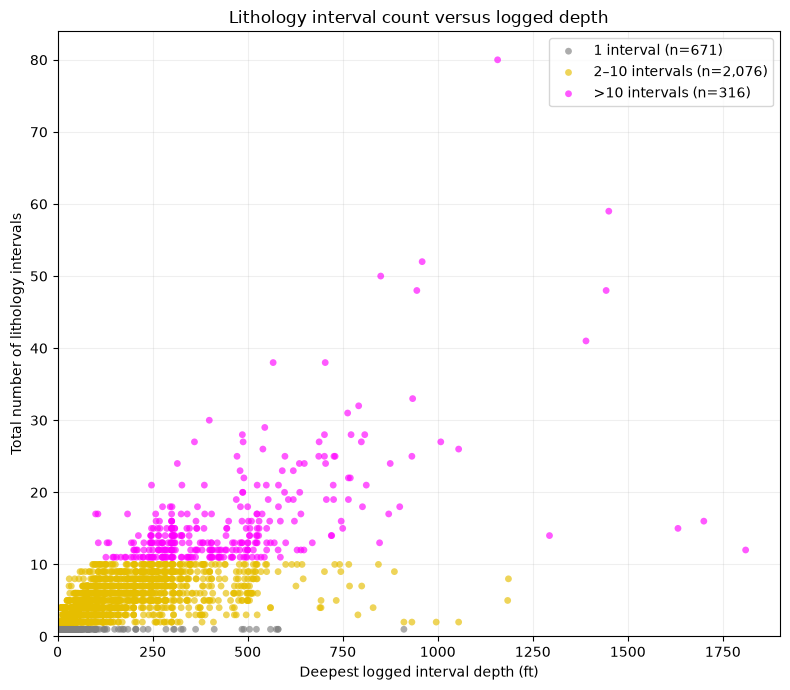

Figure 1: 3,029 wells with both depths
Figure 2: 3,063 wells with valid logged depths
Figures and summary CSV saved to: /home/chaoyiwang/workspace/boardman_geological_model/05_notebooks/figures


In [22]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "05_notebooks":
    ROOT = ROOT.parent

WELLS_DIR = ROOT / "01_raw/wells"
if not WELLS_DIR.is_dir():
    raise FileNotFoundError(f"Cannot find wells directory: {WELLS_DIR}")

OUTPUT_DIR0 = ROOT / "03_processed/wells"
OUTPUT_DIR0.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR1 = ROOT / "05_notebooks/figures"
OUTPUT_DIR1.mkdir(parents=True, exist_ok=True)

records = []

for path in sorted(WELLS_DIR.rglob("lithology.csv")):
    try:
        lith = pd.read_csv(path).replace(r"^\s*$", pd.NA, regex=True)
        lith = lith.dropna(how="all")
    except pd.errors.EmptyDataError:
        continue

    if lith.empty or "to_ft" not in lith.columns:
        continue

    depths = pd.to_numeric(lith["to_ft"], errors="coerce")
    depths = depths[depths.ge(0) & depths.lt(float("inf"))]
    if depths.empty:
        continue

    metadata_path = path.parent / "metadata.json"
    metadata = {}
    if metadata_path.exists():
        with metadata_path.open(encoding="utf-8") as f:
            metadata = json.load(f)

    completion = pd.to_numeric(
        metadata.get("completed_depth"), errors="coerce"
    )
    if pd.notna(completion) and (
        completion < 0 or completion == float("inf")
    ):
        completion = float("nan")

    records.append({
        "well_number": path.parent.name,
        "completed_depth_ft": completion,
        "deepest_logged_depth_ft": depths.max(),
        "interval_count": len(lith),
    })

if not records:
    raise ValueError("No non-empty lithology files with valid depths found.")

df = pd.DataFrame(records)
df.to_csv(OUTPUT_DIR0 / "lithology_depth_summary.csv", index=False)

# Non-overlapping categories.
groups = [
    ("1 interval", df["interval_count"].eq(1), "gray"),
    ("2–10 intervals", df["interval_count"].between(2, 10), "#E6BE00"),
    (">10 intervals", df["interval_count"].gt(10), "magenta"),
]

def scatter_groups(ax, x, y):
    for label, mask, color in groups:
        subset = df.loc[mask].dropna(subset=[x, y])
        ax.scatter(
            subset[x], subset[y],
            color=color, s=24, alpha=0.65, edgecolors="none",
            label=f"{label} (n={len(subset):,})",
        )
    ax.set_axisbelow(True)
    ax.grid(alpha=0.2)


# Figure 1
fig, ax = plt.subplots(figsize=(8, 7))
scatter_groups(ax, "completed_depth_ft", "deepest_logged_depth_ft")

paired = df.dropna(subset=["completed_depth_ft"])
if not paired.empty:
    upper = max(
        paired["completed_depth_ft"].max(),
        paired["deepest_logged_depth_ft"].max(),
        1,
    ) * 1.05
    ax.plot([0, upper], [0, upper], "k--", lw=1, label="1:1 reference")
    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_aspect("equal", adjustable="box")

ax.set(
    xlabel="Well completion depth (ft)",
    ylabel="Deepest logged interval depth (ft)",
    title="Completion depth versus deepest logged depth",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR1 / "completion_vs_logged_depth.png", dpi=300)
plt.show()


# Figure 2
fig, ax = plt.subplots(figsize=(8, 7))
scatter_groups(ax, "deepest_logged_depth_ft", "interval_count")

ax.set(
    xlabel="Deepest logged interval depth (ft)",
    ylabel="Total number of lithology intervals",
    title="Lithology interval count versus logged depth",
    xlim=(0, None),
    ylim=(0, None),
)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR1 / "logged_depth_vs_interval_count.png", dpi=300)
plt.show()

print(f"Figure 1: {len(paired):,} wells with both depths")
print(f"Figure 2: {len(df):,} wells with valid logged depths")
print(f"Figures and summary CSV saved to: {OUTPUT_DIR1}")